# Tennessee Eastman Process — Drift-Erkennung

Wendet die fünf Drift-Detektoren KSWIN, ADWIN, DDM, EDDM und den Schwellwert-Detektor `RMSE` (`drift_detection.py`) auf den normierten Modellfehler des Fehlerfallstroms (IDV 29) aus *tep_model* an. Als Ground Truth dient das gemessene Driftsignal `driftf` aus *tep_generation*, nicht eine Rekonstruktion der Driftfunktion. Der Strom ist ein durchgehender Lauf über rund 17 400 h, in dem der Sägezahn mehrfach zurückspringt; getunt und bewertet wird auf diesen Sudden Drifts, wie im synthetischen Fall. `RMSE` ist die Überwachung eines Performance-Indikators (Gama et al. 2014, Abschn. 3.2) in ihrer einfachsten Form und dient als Vergleichsmaßstab für die vier statistischen Verfahren.

In [15]:
FORCE_RECOMPUTE = False  # True = alle Cache-Stufen neu rechnen (Tuning + nachgelagerte Laeufe)
IS_FINAL = True  # True: schreibt zusaetzlich den stabilen, eingebundenen Stand; False: nur Archiv

In [16]:
# --- Konstanten ---
SEED = 42
RUN_ID = "8165f7ca" # None   # None -> neuestes Modell
ERROR_VARIANT = {"idv": 29, "amp": 0.3}   # None -> neuester Fehlerfall; sonst z. B. {"idv": 29, "amp": 0.3}
SAMPLES_PER_H = 20
DETECTORS = ["KSWIN", "ADWIN", "DDM", "EDDM", "RMSE"]
N_TRIALS  = {
    "KSWIN": 40,
    "ADWIN": 40,
    "RMSE": 40,
    "DDM": 200,
    "EDDM": 200,
}
# 500 Trials fuer DDM/EDDM haben am 2026-09-02 im synthetischen Fall nichts
# gebracht: TPE zieht unabhaengig davon nur n_startup_trials = 10 Zufallspunkte,
# und die ersten 200 Trials sind bei gleichem Seed ohnehin identisch. 200 bleibt.
DOWNSAMPLE = 5     # Tuning nur auf jedem q-ten Punkt; run_detector ist eine
                   # Python-Schleife, bei 350k Schritten sonst stundenlang.

# Gewichte der Tuning-Zielfunktion: (Recall, Verzug, Praezision). Alle drei
# Terme liegen in [0, 1], die Gewichte sind also direkt vergleichbar. Recall
# wiegt doppelt so schwer wie Praezision -- ein verpasstes Ereignis ist teurer
# als ein Fehlalarm, aber nicht beliebig viel teurer. Frueher stand hier
# (3.0, 0.3, 0.05) auf einem unbeschraenkten Fehlalarm-Term, der nur auf dem
# stabilen Sechstel des Stroms gemessen wurde; damit gewann Dauerfeuer.
WEIGHTS = (3.0, 0.3, 1.5)

# Kandidaten je Detektor, die nach dem Tuning auf dem VOLLEN Raster gegengeprueft
# werden. Das Tuning laeuft auf jedem DOWNSAMPLE-ten Punkt, und die Rangfolge
# dort stimmt nicht zwingend mit der auf dem vollen Strom ueberein.
TOP_K = 5

# Der Fehlalarm-Term ist log10(1 + Fehlalarme je Ereignis) / FA_DECADES, gekappt
# bei 1: 0 = kein Fehlalarm, 1 = 1000 Fehlalarme je Ereignis. Logarithmisch,
# weil die Kandidaten sich ueber Groessenordnungen unterscheiden -- ein linearer
# Term aus (1 - precision) liegt dort fuer alle bei 0,98 bis 0,99 und traegt
# keinen Gradienten; das Tuning optimiert dann nur den Verzug und senkt ihn,
# indem es haeufiger feuert.
FA_DECADES = 3.0

# Toleranz und Cooldown relativ statt als feste Schrittzahl: als Schrittzahl
# bedeuten sie in den beiden Stroemen Verschiedenes (der synthetische Strom
# tastet je Minute ab, der TEP je 3 Minuten, und die Ereignisabstaende
# unterscheiden sich um Faktor 3). Die Toleranz ist ein Anteil des mittleren
# Ereignisabstands, der Cooldown ein Anteil der Stromlaenge. Gerundet wird auf
# QUANT Schritte, damit eine geringfuegig andere Ereignislage den Cache nicht
# neu schluesselt.
TOLERANCE_REL = 0.0092   # Anteil des mittleren Ereignisabstands -> TOLERANCE
COOLDOWN_REL  = 0.0095   # Anteil der Stromlaenge -> COOLDOWN (nur Darstellung)
QUANT = 100              # Rundung beider abgeleiteter Groessen [Schritte]

PLOT_FRAC = 0.05             # Anteil geplotteter Punkte
PLOT_YLIM = (-1e2, 1e2)      # symlog-Bereich der Fehlerachse
PLOT_EPOCH = "1970-01-01"    # Zeitstempel-Ursprung wie im synthetischen Fall
PLOT_MONTHS = 6             # None -> ganzer Strom

In [17]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "tep"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

In [18]:
import numpy as np

rng = np.random.default_rng(SEED)

Daten laden: gescorte Test- und Fehlerfalldaten aus dem Modell-Notebook

In [19]:
from src.utils import run_registry as rr
rr.assert_current()   # veraltetes Modul im Kernel? (s. drift_detection)
ledger = rr.run_ledger(work_dir)
data_store = rr.tep_data_store(data_dir)
model_store = rr.tep_model_store(model_dir)
plot_store = rr.tep_plot_store(plot_dir, ledger=ledger)
res_store = rr.tep_results_store(results_dir, ledger=ledger)

_mp = model_store.latest("model")
if _mp is None:
    raise FileNotFoundError("Kein model-Artefakt. Bitte tep_model.ipynb ausfuehren.")
model_id = model_store.parse_id(_mp, "model") if RUN_ID is None else RUN_ID

test_scored = data_store.load("data_scored_production", run_id=model_id, rename=True)
model_cfg = rr.RunConfig.from_document(test_scored.attrs.get("config", test_scored.attrs))

error_scored, scored_error_cfg = rr.load_section(
    data_store, "data_scored_error", model_cfg, "error", ERROR_VARIANT)
error_variant = scored_error_cfg.sections["error"]
ledger.bind("detection", parents={"model": scored_error_cfg.id})
print(f"model_id = {model_id} | error_run_id = {scored_error_cfg.id} "
      f"(IDV {error_variant['idv']}, amp {error_variant['amp']})")

model_id = 8165f7ca | error_run_id = 4f0275a4 (IDV 29, amp 0.3)


## Fehlerstrom normieren

Der Modellfehler des Fehlerfallstroms wird mit Mittelwert und Streuung des drift-freien Testfehlers normiert, konsistent zur Normierung im synthetischen Fall.

In [20]:
import pandas as pd

_err_free = test_scored["model_error"].to_numpy(dtype=float)
NORM_MEAN = float(np.nanmean(_err_free))
NORM_STD = float(np.nanstd(_err_free)) or 1.0

error_stream = np.nan_to_num((error_scored["model_error"].to_numpy(dtype=float) - NORM_MEAN) / NORM_STD)
reset_pos = np.flatnonzero(error_scored["reset"].to_numpy())
N = len(error_stream)

# Darstellungszeit als Zeitstempel, analog tep_model und syn_detection.
t_h = np.arange(N) / SAMPLES_PER_H
plot_index = pd.to_datetime(t_h * 3600.0, unit="s", origin=pd.Timestamp(PLOT_EPOCH))

print(f"Fehlerstrom: {N} Zeitschritte ({N / SAMPLES_PER_H:.0f} h, bis {plot_index[-1]:%d.%m.%Y}), "
      f"{len(reset_pos) + 1} Laeufe | Normierung: mean={NORM_MEAN:.4g}, std={NORM_STD:.4g}")
print(f"Norm. Fehler: max|z|={np.nanmax(np.abs(error_stream)):.1f}, "
      f"99.9%-Quantil={np.nanquantile(np.abs(error_stream), 0.999):.1f} -> PLOT_YLIM ggf. anpassen")

Fehlerstrom: 351361 Zeitschritte (17568 h, bis 03.01.1972), 1 Laeufe | Normierung: mean=-0.0005752, std=0.01314
Norm. Fehler: max|z|=18.6, 99.9%-Quantil=15.3 -> PLOT_YLIM ggf. anpassen


## Driftsignal

Das Driftsignal wird nicht rekonstruiert, sondern aus den Daten gelesen: `driftf` steht als Spalte in `data_scored_error` und ist als Verhältnis der aufgezeichneten zur nominalen Strippertemperatur punktweise exakt (identisch zu *tep_model*). Damit hängt hier keine Auswertung mehr an einer C-Übersetzung, und Periode, Amplitude und Seed der Driftfunktion müssen nicht im Notebook stehen.

In [21]:
# driftf = Stripper Temp(Fehler) / Stripper Temp(nominal), aus tep_generation.
cd_signal = error_scored["driftf"].to_numpy(dtype=float) - 1.0
drift_segment = error_scored["drift_segment"].to_numpy(dtype=float)

_seg = (pd.DataFrame({"t": error_scored["time"].to_numpy(dtype=float), "seg": drift_segment})
          .groupby("seg")["t"].agg(["min", "max", "count"]))
print(f"Driftsignal (gemessen): min={np.nanmin(cd_signal):.3f}, "
      f"max={np.nanmax(cd_signal):.3f} | "
      f"Kalibrierfaktor in [{1 + np.nanmin(cd_signal):.4f}, {1 + np.nanmax(cd_signal):.4f}]")
print(f"{len(_seg)} Driftsegmente:")
print(_seg.to_string(float_format=lambda v: f"{v:.1f}"))

Driftsignal (gemessen): min=-0.138, max=0.147 | Kalibrierfaktor in [0.8625, 1.1470]
12 Driftsegmente:
         min     max  count
seg                        
0.0      0.0     0.0      1
1.0      0.1  1693.7  33873
2.0   1693.7  3652.5  39177
3.0   3652.6  5390.1  34751
4.0   5390.1  7018.2  32563
5.0   7018.2  8623.0  32095
6.0   8623.0 10581.2  39165
7.0  10581.2 12216.0  32696
8.0  12216.1 14002.6  35731
9.0  14002.6 15613.9  32227
10.0 15614.0 17413.5  35993
11.0 17413.6 17568.0   3089


## Ground Truth: Sudden Drifts

Am Ende jeder Sägezahn-Periode springt $c(t)$ von der negativen Flanke auf einen positiven Startwert zurück. Dieser Rücksprung ist der Sudden Drift, auf den getunt und bewertet wird — dieselbe Ground Truth wie in *syn_detection*.

Die Sprungstellen kommen aus der Spalte `drift_segment` und nicht aus einer Schwelle auf $c(t)$: das gemessene Signal rauscht, ein Kriterium auf `diff` träfe tausende Scheingrenzen. Segment 0 ist der einzelne Abtastpunkt bei $t = 0$, der Beginn von Segment 1 ist der Aufzeichnungsbeginn; beides ist kein detektierbares Ereignis und zählt nicht mit. Ebenso wenig zählt ein Rücksprung, dessen Toleranzfenster über das Ende der Aufzeichnung hinausreicht — er ist grundsätzlich nicht erkennbar und würde den Recall aller Detektoren gleichermaßen drücken.

In [22]:
import drift_detection as dd

# Der Kernel haelt bereits importierte Module fest: eine Aenderung an
# src/drift_detection.py wirkt erst nach einem Neustart. assert_current()
# vergleicht die beim Import berechnete Pruefsumme der Datei mit einem frischen
# Blick darauf und deckt damit JEDE Aenderung ab. Die frueheren Waechter
# prueften nur ein einzelnes Merkmal und liessen eine geaenderte Parametergrenze
# unbemerkt durch.
dd.assert_current()

# Kennung des Optuna-Suchraums, gebildet aus dem GELADENEN Code-Objekt. Nicht
# ueber inspect.getsource: das liest die Quelldatei und liefert in einem
# veralteten Kernel die neue Fassung, waehrend die alte laeuft.
SPACE_ID = dd.search_space_id()
print(f"drift_detection {dd.MODULE_SHA} | Suchraum {SPACE_ID}")

# Segmentgrenzen statt Schwelle auf dem verrauschten c(t) (s. o.). Ereignisse,
# deren Toleranzfenster nicht mehr in den Strom passt, sind grundsaetzlich nicht
# erkennbar und wuerden den Recall systematisch druecken -- sie zaehlen nicht mit.
_bounds = [int(i) for i in np.flatnonzero(np.diff(drift_segment) > 0) + 1
           if drift_segment[i] >= 2]

# Der Ereignisabstand wird aus den ungefilterten Grenzen bestimmt, sonst haenge
# die Toleranz an einer Auswahl, die sie selbst trifft.
_ev = _bounds
# Toleranz und Cooldown aus den relativen Vorgaben ableiten (s. Konstanten).
def _quant(v):
    return int(max(QUANT, round(v / QUANT) * QUANT))

EVENT_SPACING = float(np.mean(np.diff(_ev))) if len(_ev) > 1 else float(N)
TOLERANCE = _quant(TOLERANCE_REL * EVENT_SPACING)
COOLDOWN = _quant(COOLDOWN_REL * N)
print(f"mittlerer Ereignisabstand {EVENT_SPACING:.0f} Schritte | "
      f"TOLERANCE = {TOLERANCE} ({100 * TOLERANCE / EVENT_SPACING:.2f} %) | "
      f"COOLDOWN = {COOLDOWN} ({100 * COOLDOWN / N:.2f} % der Stromlaenge)")

sudden_idx = [i for i in _bounds if i + TOLERANCE < N]
drift_active = dd.drift_active_mask(cd_signal, rel_floor=0.1)

print(f"{len(sudden_idx)} Sudden Drifts bei "
      + ", ".join(f"{i / SAMPLES_PER_H:.0f} h" for i in sudden_idx))
if len(_bounds) > len(sudden_idx):
    print("verworfen (Toleranzfenster reicht ueber das Stromende hinaus): "
          + ", ".join(f"{i / SAMPLES_PER_H:.0f} h" for i in _bounds[len(sudden_idx):]))
print(f"Driftaktiv: {drift_active.sum()} von {N} Schritten ({100 * drift_active.mean():.0f} %)")

drift_detection 7334ee4d | Suchraum 8eb6c5b4
mittlerer Ereignisabstand 34933 Schritte | TOLERANCE = 300 (0.86 %) | COOLDOWN = 3300 (0.94 % der Stromlaenge)
10 Sudden Drifts bei 1694 h, 3653 h, 5390 h, 7018 h, 8623 h, 10581 h, 12216 h, 14003 h, 15614 h, 17414 h
Driftaktiv: 296199 von 351361 Schritten (84 %)


## Parameter-Tuning (Optuna)

In [23]:
from types import SimpleNamespace
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

det_cfg = model_cfg.compose(error=error_variant,
                      detector={"events": "sudden", "detectors": DETECTORS,
                      "n_trials": N_TRIALS, "tolerance": TOLERANCE,
                      "weights": list(WEIGHTS), "fa_decades": FA_DECADES, "space": SPACE_ID,
                      "downsample": DOWNSAMPLE,
                      "cooldown": COOLDOWN})

_tuning_loaded_from_cache = model_store.exists("detect_tuning", det_cfg, rekey=True) and not FORCE_RECOMPUTE
if _tuning_loaded_from_cache:
    _tuning = model_store.load("detect_tuning", det_cfg, rename=True, rekey=True)
    _tuning.setdefault("top_params", {})   # aeltere Artefakte kennen den Schluessel nicht
else:
    _tuning = {"best_params": {}, "user_attrs": {}, "best_value": {}, "top_params": {}}

_retuned = False
studies, best_params = {}, {}

for _name in DETECTORS:
    if _name in _tuning["best_params"]:
        best_params[_name] = _tuning["best_params"][_name]
        studies[_name] = SimpleNamespace(
            best_value=_tuning["best_value"][_name],
            best_trial=SimpleNamespace(user_attrs=_tuning["user_attrs"][_name]))
        print(f"{_name:6s} aus Cache geladen")
        continue
    print(f"{_name:6s} wird getunt...")
    studies[_name] = dd.tune_detector(
        _name, error_stream, sudden_idx, drift_active,
        tolerance=TOLERANCE, n_trials=N_TRIALS[_name], downsample=DOWNSAMPLE, seed=SEED,
        weights=WEIGHTS, fa_decades=FA_DECADES)
    best_params[_name] = studies[_name].best_params
    _tuning["best_params"][_name] = best_params[_name]
    _tuning["user_attrs"][_name] = dict(studies[_name].best_trial.user_attrs)
    _tuning["best_value"][_name] = float(studies[_name].best_value)
    # Die TOP_K besten Trials fuer die Gegenpruefung auf dem vollen Raster.
    _tuning["top_params"][_name] = [
        dict(t.params) for t in sorted(
            (t for t in studies[_name].trials if t.value is not None),
            key=lambda t: t.value)[:TOP_K]]
    _retuned = True
    print(f"{_name:6s} tuning abgeschlossen: score={studies[_name].best_value:.3f}")

if _retuned:
    model_store.save(_tuning, "detect_tuning", det_cfg)

for _name in DETECTORS:
    a = studies[_name].best_trial.user_attrs
    # mean_delay aus dem Tuning zaehlt Schritte des heruntergetakteten Rasters.
    _delay_h = a["mean_delay"] * DOWNSAMPLE / SAMPLES_PER_H
    print(f"{_name:6s} score={studies[_name].best_value:.3f} | recall={a['recall']:.2f} "
          f"prec={a['precision']:.2f} delay={_delay_h:.1f} h "
          f"false={a['n_false']:4d} -> {best_params[_name]}")

KSWIN  aus Cache geladen
ADWIN  aus Cache geladen
DDM    aus Cache geladen
EDDM   aus Cache geladen
RMSE   aus Cache geladen
KSWIN  score=1.070 | recall=1.00 prec=0.01 delay=6.6 h false= 740 -> {'min_num_instances': 65, 'alpha': 1.1297111371954272e-06, 'num_test_instances': 21}
ADWIN  score=0.944 | recall=1.00 prec=0.02 delay=3.8 h false= 536 -> {'delta': 0.014910600988139108, 'clock': 1, 'min_window_size': 7}
DDM    score=2.476 | recall=0.30 prec=0.12 delay=5.8 h false=  23 -> {'drift_level': 3.842417626417088, 'warning_level': 2.6817377990910116, 'min_num_instances': 407, 'err_threshold': 4.391470943853009}
EDDM   score=2.507 | recall=0.30 prec=0.09 delay=4.8 h false=  32 -> {'alpha': 0.9545862049007362, 'beta': 0.9463263091675154, 'min_num_misclassified_instances': 411, 'err_threshold': 3.5764225737929993}
RMSE   score=2.786 | recall=0.20 prec=0.09 delay=7.4 h false=  20 -> {'window': 736, 'threshold': 6.187255599871848}


### Gegenprüfung auf dem vollen Raster

Das Tuning wertet nur jeden `DOWNSAMPLE`-ten Punkt aus — notwendig, weil `run_detector` eine Python-Schleife über den ganzen Strom ist, aber es verschiebt den Arbeitspunkt und damit die Rangfolge. Der Docstring von `tune_detector` verlangt diese Gegenprüfung ausdrücklich.

Die `TOP_K` besten Trials je Detektor laufen deshalb noch einmal über den vollständigen Strom. Gewählt wird der mit dem besten Score dort. `tuning_metrics` weiter unten beschreibt weiterhin den besten Trial des Tunings und kann sich auf einen anderen Parametersatz beziehen als `best_params`.

In [24]:
cc_cfg = det_cfg.compose(crosscheck={"top_k": TOP_K,
                                     "candidates": _tuning.get("top_params", {})})

if model_store.exists("detect_crosscheck", cc_cfg, rekey=True) and not FORCE_RECOMPUTE:
    crosscheck = model_store.load("detect_crosscheck", cc_cfg, rename=True, rekey=True)
    print("Gegenpruefung aus Cache")
else:
    crosscheck = {}
    for _name in DETECTORS:
        _cands = list(_tuning.get("top_params", {}).get(_name) or [best_params[_name]])
        _rows = []
        for _rank, _cand in enumerate(_cands, start=1):
            _p = dict(_cand)
            _et = _p.pop("err_threshold", 0.5)
            _det = dd.build_detector(_name, **_p)
            _dr, _ = dd.run_detector(_name, _det, error_stream, err_threshold=_et)
            _m = dd.score_detections(_dr, sudden_idx, drift_active, tolerance=TOLERANCE,
                                     n=N, weights=WEIGHTS, fa_decades=FA_DECADES)
            _rows.append({"rank_tuning": _rank,
                          "params": dict(_cand),
                          "score": _m["score"], "recall": _m["recall"],
                          "fa_term": _m["fa_term"], "n_detected": _m["n_detected"]})
        crosscheck[_name] = {"chosen": min(_rows, key=lambda r: r["score"]),
                             "candidates": _rows}
    model_store.save(crosscheck, "detect_crosscheck", cc_cfg)

# Ab hier gelten die gegengeprueften Parameter.
best_params = {_name: crosscheck[_name]["chosen"]["params"] for _name in DETECTORS}
for _name in DETECTORS:
    _c = crosscheck[_name]["chosen"]
    _src = _c.get("source", "tuning")   # aeltere Crosscheck-Artefakte kennen ihn nicht
    print(f"{_name:6s} gewaehlt: {_src} (Rang {_c['rank_tuning']} von "
          f"{len(crosscheck[_name]['candidates'])}) | score={_c['score']:.3f} "
          f"recall={_c['recall']:.2f} n_det={_c['n_detected']:5d} -> {_c['params']}")

Gegenpruefung aus Cache
KSWIN  gewaehlt: tuning (Rang 1 von 5) | score=1.322 recall=1.00 n_det= 3859 -> {'min_num_instances': 65, 'alpha': 1.1297111371954272e-06, 'num_test_instances': 21}
ADWIN  gewaehlt: tuning (Rang 5 von 5) | score=1.128 recall=1.00 n_det= 1548 -> {'delta': 0.027502394288673952, 'clock': 27, 'min_window_size': 12}
DDM    gewaehlt: tuning (Rang 2 von 6) | score=3.043 recall=0.10 n_det=   36 -> {'drift_level': 4.395383189719272, 'warning_level': 3.507911417992255, 'min_num_instances': 60, 'err_threshold': 5.1496921131763}
EDDM   gewaehlt: tuning (Rang 1 von 6) | score=3.010 recall=0.20 n_det=   73 -> {'alpha': 0.9545862049007362, 'beta': 0.9463263091675154, 'min_num_misclassified_instances': 411, 'err_threshold': 3.5764225737929993}
RMSE   gewaehlt: tuning (Rang 1 von 5) | score=2.100 recall=0.50 n_det=   85 -> {'window': 736, 'threshold': 6.187255599871848}


## Vergleich der getunten Detektoren

Bewertet wird der ungefilterte Lauf. Der Cooldown ist reine Darstellungsausdünnung: KSWIN und ADWIN melden während des andauernden inkrementellen Drifts fortlaufend weiter, was die Abbildung unlesbar machen würde.

In [25]:
det_run = cc_cfg
_detections_loaded_from_cache = model_store.exists("detections", det_run, rekey=True) and not FORCE_RECOMPUTE and not _retuned
if _detections_loaded_from_cache:
    _det_cache = model_store.load("detections", det_run, rename=True, rekey=True)
    tuned = _det_cache["tuned"]
    for _name in DETECTORS:
        print(f"{_name:6s}: {len(tuned[_name][0]):3d} Drift(s) (getunt)")
    plot_thinned = _det_cache["plot_thinned"]
    for _name in ["KSWIN", "ADWIN"]:
        print(f"{_name:6s}: {len(plot_thinned[_name][0]):3d} Drift(s) "
              f"(plot-cooldown={COOLDOWN}, aus Cache)")
else:
    tuned = {}
    for _name, _p in best_params.items():
        _p = dict(_p)
        _et = _p.pop("err_threshold", 0.5)
        _det = dd.build_detector(_name, **_p)
        tuned[_name] = dd.run_detector(_name, _det, error_stream, err_threshold=_et)
        print(f"{_name:6s}: {len(tuned[_name][0]):3d} Drift(s) (getunt)")
    plot_thinned = {}
    for _name in ["KSWIN", "ADWIN"]:
        _p = dict(best_params[_name]); _p.pop("err_threshold", None)
        _det = dd.build_detector(_name, **_p)
        plot_thinned[_name] = dd.run_detector(_name, _det, error_stream, cooldown=COOLDOWN)
        print(f"{_name:6s}: {len(plot_thinned[_name][0]):3d} Drift(s) (plot-cooldown={COOLDOWN})")
    model_store.save({"tuned": tuned, "plot_thinned": plot_thinned}, "detections", det_run)

KSWIN : 3859 Drift(s) (getunt)
ADWIN : 1548 Drift(s) (getunt)
DDM   :  36 Drift(s) (getunt)
EDDM  :  73 Drift(s) (getunt)
RMSE  :  85 Drift(s) (getunt)
KSWIN : 105 Drift(s) (plot-cooldown=3300, aus Cache)
ADWIN : 103 Drift(s) (plot-cooldown=3300, aus Cache)


Die folgenden Abbildungen zeigen je Detektor den normierten Modellfehler auf symlog-Ordinate, das gemessene Driftsignal $c(t)$ auf der rechten Achse und die Detektionszeitpunkte (KSWIN/ADWIN ausgedünnt, die übrigen ungefiltert). Dargestellt sind die ersten `PLOT_MONTHS` Monate; die Kennzahlen weiter unten beziehen sich auf den vollständigen Strom.

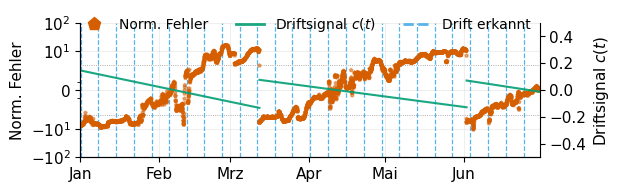

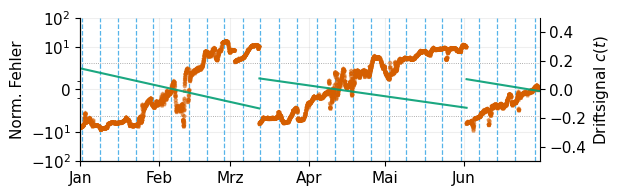

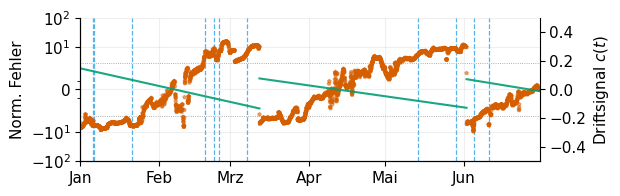

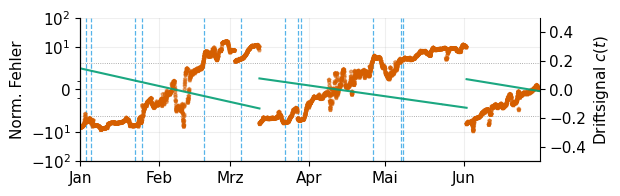

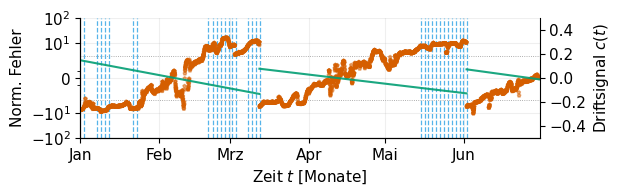

In [26]:
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

rng_plot = np.random.default_rng(SEED)

_win = np.arange(N)
if PLOT_MONTHS is not None:
    _win = np.flatnonzero(plot_index < pd.Timestamp(PLOT_EPOCH) + pd.DateOffset(months=PLOT_MONTHS))
n_plot = len(_win)

# Der Schwellwert-Detektor kommt ungefiltert dazu: 85 Detektionen auf dem
# vollen Strom, also dieselbe Groessenordnung wie DDM und EDDM. Ausgeduennt
# werden nur KSWIN und ADWIN, die vier- bis fuenfstellig feuern.
detections = {"KSWIN": plot_thinned["KSWIN"][0], "ADWIN": plot_thinned["ADWIN"][0],
              "DDM": tuned["DDM"][0], "EDDM": tuned["EDDM"][0],
              "RMSE": tuned["RMSE"][0]}

for j, (name, drifts) in enumerate(detections.items()):
    fig, ax, ax2 = ts.error_timeseries(
        plot_index[_win],
        [(error_stream[_win], "drift_afflicted", "Norm. Fehler")],
        cd=cd_signal[_win],
        detections=[plot_index[d] for d in drifts if d < n_plot],
        xlabel="Zeit $t$ [Monate]" if j == len(detections) - 1 else None,
        cd_label="Driftsignal $c(t)$",
        ylim=PLOT_YLIM, cd_amp=0.5, cd_tick_step=0.2,
        frac=PLOT_FRAC, rng=rng_plot,
        legend=dict(bbox_to_anchor=[0.49, 1.15], loc="upper center", ncols=3) if j == 0 else False,
    )
    fig.tight_layout()
    plot_store.save_figure(fig, f"detection_{name.lower()}", det_run, final=IS_FINAL,
                           savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
    plt.show()

## Ergebnisse speichern

In [27]:
from src.utils import results_export as rx

def _full_metrics(drifts):
    return dd.score_detections(drifts, sudden_idx, drift_active, tolerance=TOLERANCE,
                               n=N, weights=WEIGHTS, fa_decades=FA_DECADES)


def _chance(n_det):
    """Recall und Verzug, die eine blind mit dieser Rate feuernde Folge erreicht.

    Bezugsgroesse fuer die Interpretation: ein Detektor, der alle N/n_det
    Schritte meldet, trifft ein Ereignis mit 1 - exp(-n_det * tolerance / N),
    und sein mittlerer Verzug ist der halbe Detektionsabstand. Ohne diese
    Groesse liest sich ein Recall von 1,00 als perfekt, auch wenn er es nicht ist.
    """
    if not n_det:
        return {"recall": 0.0, "mean_delay": None}
    return {"recall": float(1.0 - np.exp(-n_det * TOLERANCE / N)),
            "mean_delay": float(N / (2 * n_det))}

# tuning_metrics stammen aus dem Tuning und liegen auf dem um DOWNSAMPLE
# heruntergetakteten Raster; full_stream ist der ungefilterte Lauf ueber den
# vollstaendigen Strom -- nur diese Werte gehen in die LaTeX-Makros.
detector_results = {}
for _name in DETECTORS:
    _ua = studies[_name].best_trial.user_attrs
    _drifts = tuned[_name][0]
    _m = _full_metrics(_drifts)
    _entry = {
        "best_params": best_params[_name],
        "tuning_metrics": {_k: _ua.get(_k) for _k in
            ["recall", "precision", "fa_term", "mean_delay", "n_false",
             "n_false_stable", "fa_per_true", "n_sudden", "n_detected", "score"]},
        "tuning_score": studies[_name].best_value,
        "full_stream": {"n_detected": _m["n_detected"], "recall": _m["recall"],
                        "precision": _m["precision"], "fa_term": _m["fa_term"],
                        "mean_delay": _m["mean_delay"],
                        "n_false": _m["n_false"], "n_false_stable": _m["n_false_stable"]},
        "chance": _chance(_m["n_detected"]),
        "crosscheck": {"top_k": TOP_K,
                       "rank_tuning": crosscheck[_name]["chosen"]["rank_tuning"],
                       "source": crosscheck[_name]["chosen"].get("source", "tuning"),
                       "candidates": crosscheck[_name]["candidates"]},
        "drift_indices": list(_drifts),
    }
    if _name in plot_thinned:
        _entry["plot_thinned"] = {"plot_cooldown": COOLDOWN,
                                  "n_shown": len(plot_thinned[_name][0])}
    detector_results[_name] = _entry

(rx.ResultDoc()
   .integer("n_samples", N)
   .set("samples_per_hour", SAMPLES_PER_H)
   .integer("n_sudden_drifts", len(sudden_idx))
   .set("sudden_drift_indices", sudden_idx)
   .set("reset_indices", reset_pos)
   .integer("n_active", np.sum(drift_active))
   .set("tolerance", TOLERANCE)
   .set("tolerance_rel", TOLERANCE_REL)
   .num("event_spacing", EVENT_SPACING, 1)
   .set("plot_cooldown", COOLDOWN)
   .set("cooldown_rel", COOLDOWN_REL)
   .set("tuning", {"n_trials": N_TRIALS, "downsample": DOWNSAMPLE,
                   "weights": list(WEIGHTS), "fa_decades": FA_DECADES,
                   "top_k": TOP_K})
   .set("detectors", detector_results)
   .save(res_store, "detection", det_run, final=IS_FINAL,
         parents={"model": scored_error_cfg.id}))

Umfassende Ergebnisse -> C:\git\process_optimization_concept_drift\results\tep_detection.json


'C:\\git\\process_optimization_concept_drift\\results\\tep_detection.json'

In [28]:
from src.utils import latex_export as lx

mx = lx.MacroExport("automatisch erzeugt aus tep_detection.ipynb - nicht manuell editieren")

mx.comment("Parameter (Hash-relevant)")
mx.integer("tepdriftNSudden", len(sudden_idx))
mx.num("tepdriftToleranceH", TOLERANCE / SAMPLES_PER_H, 0)
mx.num("tepdriftTolerancePct", 100 * TOLERANCE / EVENT_SPACING, 2)
mx.num("tepdriftCooldownH", COOLDOWN / SAMPLES_PER_H, 0)

mx.comment("Ergebnisse (Detektionskennzahlen je Detektor)")
for _name in DETECTORS:
    _e = detector_results[_name]
    _fs = _e["full_stream"]
    mx.num(f"tepdrift{_name}Recall", _fs["recall"], 2)
    mx.num(f"tepdrift{_name}Precision", _fs["precision"], 2)
    mx.num(f"tepdrift{_name}Chance", _e["chance"]["recall"], 2)   # Recall bei blindem Feuern
    mx.num(f"tepdrift{_name}DelayH", _fs["mean_delay"] / SAMPLES_PER_H, 1)
    mx.integer(f"tepdrift{_name}False", _fs["n_false"])
    mx.integer(f"tepdrift{_name}Drifts", _fs["n_detected"])
    if "plot_thinned" in _e:
        mx.integer(f"tepdrift{_name}DriftsPlot", _e["plot_thinned"]["n_shown"])

mx.save(res_store, "detection", det_run, final=IS_FINAL)

LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\tep_detection.tex

% automatisch erzeugt aus tep_detection.ipynb - nicht manuell editieren

% Parameter (Hash-relevant)
\newcommand{\tepdriftNSudden}{10}
\newcommand{\tepdriftToleranceH}{15}
\newcommand{\tepdriftTolerancePct}{0{,}86}
\newcommand{\tepdriftCooldownH}{165}

% Ergebnisse (Detektionskennzahlen je Detektor)
\newcommand{\tepdriftKSWINRecall}{1{,}00}
\newcommand{\tepdriftKSWINPrecision}{0{,}01}
\newcommand{\tepdriftKSWINChance}{0{,}96}
\newcommand{\tepdriftKSWINDelayH}{1{,}5}
\newcommand{\tepdriftKSWINFalse}{3825}
\newcommand{\tepdriftKSWINDrifts}{3859}
\newcommand{\tepdriftKSWINDriftsPlot}{105}
\newcommand{\tepdriftADWINRecall}{1{,}00}
\newcommand{\tepdriftADWINPrecision}{0{,}01}
\newcommand{\tepdriftADWINChance}{0{,}73}
\newcommand{\tepdriftADWINDelayH}{1{,}7}
\newcommand{\tepdriftADWINFalse}{1531}
\newcommand{\tepdriftADWINDrifts}{1548}
\newcommand{\tepdriftADWINDriftsPlot}{103}
\newcommand{\tepdriftDDMRecall

'C:\\git\\process_optimization_concept_drift\\results\\tep_detection.tex'